In [1]:
import pandas as pd
import numpy as np
import pickle, os
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [ ]:
data_dir = 'cis-trans-pbmetad/ct_data_oppc'

omegas_file = f'{data_dir}/timeomega.dat'

with open(omegas_file, 'r') as f:
    # Count total lines minus comment lines
    total_rows = sum(1 for line in f if not line.startswith('#'))

# Now, use `skiprows` to skip rows directly in pandas, excluding indices for FIELDS and comments
df = pd.read_csv(
    omegas_file,
    delim_whitespace=True
#    names=columns
    #skiprows=skip_every_20th(1, total_rows)  # Start after '#! FIELDS' line
)

# Display the DataFrame
df

/var/folders/d8/y2dvs1ln1gjcwccrkvtffr240000gn/T/ipykernel_11309/2715359899.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,time,omega1,omega2,omega3
0,0.02,2.920840,2.893603,3.097813
1,0.42,2.302964,-2.820351,2.793346
2,0.82,2.823639,-2.602560,-2.795064
3,1.22,3.056885,-2.470381,-3.033391
4,1.62,3.079291,-2.744618,-2.858711
...,...,...,...,...
2507358,988471.08,0.063649,2.961058,-0.214932
2507359,988471.10,-0.000804,2.965537,-0.319893
2507360,988471.12,-0.023433,2.960665,-0.201649
2507361,988471.14,0.092578,3.008329,-0.006666


In [4]:
# Extract the omegas 
omega_df = df[['omega1', 'omega2', 'omega3']]
# omega_df.astype(float)
omega_np = omega_df.to_numpy()
omega_np.shape

(2507363, 3)

In [5]:
def omega2cistrans(omega):
    """Converts a sequence of float omega angles (in degrees) to an array of ints: 0 cis and 1 trans."""
    
    shifted_omega = (omega + 90.0) % 360.0 - 90.0 # shift into (-90, 270) range to avoid periodic boundaries
    
    cistrans = np.where(shifted_omega > 90.0, 1, 0).astype(int)
    return cistrans

# Convert the radians to angles
omega_angle = omega_np * (180 / np.pi)
omega_angle

array([[ 167.35180463,  165.79123949,  177.49161062],
       [ 131.95011757, -161.59420905,  160.04693652],
       [ 161.78259757, -149.11570393, -160.14537067],
       ...,
       [  -1.342612  ,  169.63360905,  -11.55363664],
       [   5.30432868,  172.36455509,   -0.38193367],
       [ -10.26327839, -173.56146392,   -3.40422874]])

In [6]:
all_cistrans = omega2cistrans(omega_angle)
all_cistrans.shape
# Find the minimum x-dimension across all arrays
min_x = min(arr.shape[0] for arr in all_cistrans)

print(f"Shortest x in all_cistrans: {min_x}")

Shortest x in all_cistrans: 3


In [7]:
def state_to_index_simple(all_cistrans):
    """Converts a (N, 3) binary array into decimal indices in [0..7]."""
    all_cistrans = np.array(all_cistrans)  # Ensure it's a numpy array
    if all_cistrans.shape[1] != 3:
        raise ValueError(f"Unexpected shape: {all_cistrans.shape}, expected (N, 3).")
    # Binary weights for [a, b, c] => 4a + 2b + c
    weights = np.array([4, 2, 1])
    states = all_cistrans @ weights  # Dot product to calculate state indices
    # Combine original states with indices for output
    new_all = np.column_stack((all_cistrans, states))
    return new_all

def index_to_state_simple(index):
    """Converts an index (0-31) into a (4,) array where:
       - The first three entries are binary bits (0 or 1),
       - The last entry is in [0..3].
    """
    # Validate the input range
    if not (0 <= index < 32):
        raise ValueError(f"Index out of range: {index}. Expected 0-31.")
    
    # Last part (x): remainder when dividing by 4
    last_part = index % 4
    
    # First three bits (a, b, c): integer division by 4 (binary form in [0..7])
    first_3_bits = np.array([(index // 4) >> i & 1 for i in reversed(range(3))], dtype=int)
    
    # Combine the binary bits and the last part
    state = np.concatenate([first_3_bits, [last_part]])
    
    return state

In [8]:
def get_transition_matrix_single_trajectory(n_traj, num_states, lagtime, pseudocount=0.25):
    """
    Compute the transition matrix for a single trajectory.
    
    Parameters
    ----------
    n_traj : ndarray
        A single trajectory of states (array of shape `(L,)`, where `L` is the length of the trajectory).
    num_states : int
        The total number of states expected.
    lagtime : int
        The lag time for the transition matrix computation.
    pseudocount : float, optional
        Value added to prevent zero counts in the matrix (default is 0.25).
    
    Returns
    -------
    T : ndarray
        A `(num_states, num_states)` transition matrix.
    """
#     # Ensure `n_traj` is actually a single trajectory, i.e., a 1D array
#     if not isinstance(n_traj, np.ndarray) or n_traj.ndim != 1:
#         raise ValueError(f"n_traj must be a 1D array. Got shape: {n_traj.shape if isinstance(n_traj, np.ndarray) else 'Non-array'}")

    # Compute the transition matrix for the single trajectory
    T = compute_transition_matrix([n_traj], num_states=num_states, lagtime=lagtime, pseudocount=pseudocount)

    # Ensure the resulting matrix is valid and has the correct shape
    if not isinstance(T, np.ndarray) or T.shape != (num_states, num_states):
        raise ValueError(f"Transition matrix must be of shape ({num_states}, {num_states}). Got shape: {T.shape if isinstance(T, np.ndarray) else 'Non-array'}")
    
    return T

In [9]:
def compute_stationary_distribution(T, lagtime):
    """Compute the stationary distribution of a transition matrix T.
    
    INPUT:
    T - Transition matrix where T_ij is the probability of transitioning i -> j.
    
    RETURN:
    pi - The stationary distribution (1D NumPy array).
    t2 - The implied timescale (in units of steps).
    """
    try:
        # Compute the implied timescale
        evals = np.linalg.eigvals(T.transpose() )  # will be something like [0.99754545 1.        ]
        evals_sorted = np.sort(evals)      # ascending order
        mu2 = evals_sorted[-2]            # second-largest eigenvalue
        #print('mu2', mu2, 'evals', evals, 'evals_sorted', evals_sorted, 'T', T)
        
        t2 = -1.0*lagtime/np.log(mu2.real)  # the implied timescale relation
        #print('evals_sorted', evals_sorted, 'mu2', mu2, 't2', t2)

        # Compute the stationary state distribution 
        n_states = T.shape[0]
        A = np.transpose(T) - np.eye(n_states)  # (T' - I)
        A = np.vstack([A, np.ones(n_states)])  # Append normalization row
        b = np.zeros(n_states + 1)
        b[-1] = 1  # Ensure probability sums to 1
        
        # Solve for stationary distribution using least squares
        pi, *_ = np.linalg.lstsq(A, b, rcond=None)
        
        # Ensure non-negative values and normalize
        pi = np.maximum(pi, 0)  # Prevent small negative values due to numerical error
        pi /= np.sum(pi)  # Normalize to sum to 1

    except Exception as e:
        print(f"Error computing stationary distribution: {e}")
        t2 = np.nan
        pi = None

    return pi, t2

In [10]:
ntraj = len(all_cistrans)
print(ntraj)

# Find the longest traj
maxlength = max( [ len(all_cistrans[i]) for i in range(ntraj) ])
print('maxlength', maxlength)

# # Make an array to store all the trajectories
# traj = np.nan * np.ones( (ntraj, maxlength, 4) )

# for i in range(ntraj):
#     n = len(all_cistrans[i])
#     traj[i, 0:n, :] = all_cistrans[i]

# traj
traj = all_cistrans
# Step 1: Convert to indexed states
traj_indexed = state_to_index_simple(traj)  # Convert `[a, b, c]` to integer indices
print("Indexed Trajectory:", traj_indexed)

# Step 2: Compute transition matrix
# Wrap the trajectory as a list because `compute_transition_matrix` expects `[trajectory]`
num_states = 8  # Total number of possible states from `[a, b, c]` (2^3 = 8)
lagtime = 1
# transition_matrix = get_transition_matrix_single_trajectory([traj_indexed], num_states=num_states, lagtime=lagtime)

# print("Transition Matrix:")
# print(transition_matrix)

2507363
maxlength 3
Indexed Trajectory: [[1 1 1 7]
 [1 1 1 7]
 [1 1 1 7]
 ...
 [0 1 0 2]
 [0 1 0 2]
 [0 1 0 2]]


In [11]:
print('traj_indexed.shape', traj_indexed.shape)
print('traj.shape', traj.shape)

traj_indexed.shape (2507363, 4)
traj.shape (2507363, 3)


In [12]:
final_column = traj_indexed[:, -1]  # Shape (120000,)

# Reshape into a matrix with shape (1, 120000)
traj_real = final_column.reshape(1, -1)
print('traj_real.shape', traj_real.shape)
traj_real

traj_real.shape (1, 2507363)


array([[7, 7, 7, ..., 2, 2, 2]])

In [13]:
# Updated parameters for your single trajectory
# traj_indexed = your_trajectory_data  # Shape (1, 200000)
num_states = 8 
lagtimes = [5, 10, 25, 50] + list(range(100, 90000, 500))
dt_in_ns = 0.0004
n_bootstrap_samples = 1  # Number of bootstrap samples to create from your single trajectory

# Store results (same as before)
pi_all_means = []
pi_all_uppers = []
pi_all_lowers = []
pi_all_stds = []
t2_all_means = []
t2_all_uppers = []
t2_all_lowers = []
t2_all_stds = []




def process_single_trajectory(traj_indexed, lagtime, num_states, n_bootstrap_samples):
    """Process single trajectory by creating bootstrap samples from segments"""
    
    # Get the single trajectory
    single_traj = traj_indexed[0]  # Shape: (200000,)
    
    # Create bootstrap samples by taking random segments
    transition_matrices = get_bootstrap_transition_matrices(
        single_traj, num_states, lagtime, n_bootstrap_samples, pseudocount=0.25
    )
    
    # Calculate the stationary population
    pi_all = []
    t2_all = []
    
    for T in transition_matrices:
        pi, t2 = compute_stationary_distribution(T, lagtime)
        pi_all.append(pi)
        t2_all.append(t2)
    
    pi_all = np.array(pi_all)
    t2_all = np.array(t2_all)
    
    # Handle t2 statistics (geometric mean and std)
    log_t2_all = [np.log(t2) for t2 in t2_all if t2 > 0]
    if log_t2_all:
        t2_mean = np.exp(np.mean(log_t2_all))
        t2_std = np.exp(np.sqrt(np.var(log_t2_all)))
    else:
        t2_mean = 0
        t2_std = 0
    
    pi_means = np.mean(pi_all, axis=0)  # Mean across bootstrap samples
    pi_std = np.std(pi_all, axis=0)     # Standard deviation
    
    return pi_means, pi_std, t2_mean, t2_std


def get_bootstrap_transition_matrices(single_traj, num_states, lagtime, n_bootstrap_samples, pseudocount=0.25):
    """
    Create bootstrap samples from a single trajectory by taking random segments
    """
    traj_length = len(single_traj)
    
    # Calculate segment length (ensure we have enough data for meaningful statistics)
    # Use segments that are long enough but allow for overlap
    segment_length = max(10000, traj_length )#// (n_bootstrap_samples // 2))  # Allow overlap
    segment_length = min(segment_length, traj_length - lagtime)
    
    transition_matrices = []
    
    for i in range(n_bootstrap_samples):
        # Randomly select start position for this bootstrap sample
        max_start = traj_length - segment_length
        if max_start <= 0:
            # If trajectory is too short, use the whole trajectory
            start_idx = 0
            end_idx = traj_length
        else:
            start_idx = np.random.randint(0, max_start)
            end_idx = start_idx + segment_length
        
        # Extract segment
        segment = single_traj[start_idx:end_idx]
        
        # Compute transition matrix for this segment
        T = compute_transition_matrix_single(segment, num_states, lagtime, pseudocount)
        
        # Debug check
        if not isinstance(T, np.ndarray) or T.ndim != 2:
            print(f"[ERROR] compute_transition_matrix_single returned invalid type/shape: {type(T)}, shape={getattr(T, 'shape', None)}")
            raise ValueError("Transition matrix must be a 2D array")
        
        transition_matrices.append(T)
    
    return transition_matrices


def compute_transition_matrix_single(segment, num_states, lagtime, pseudocount=0.25):
    """Compute transition matrix for a single trajectory segment."""
    
    C = np.zeros((num_states, num_states))  # Initialize count matrix
    
    for t in range(len(segment) - lagtime):
        from_state = segment[t]
        to_state = segment[t + lagtime]
        
        # Skip NaN transitions
        if np.isnan(from_state) or np.isnan(to_state):
            continue
            
        # Convert states to integers for indexing
        from_state = int(from_state)
        to_state = int(to_state)
        
        # Ensure states are within valid range
        if 0 <= from_state < num_states and 0 <= to_state < num_states:
            C[from_state, to_state] += 1.0
    
    # Add pseudocounts to avoid zero entries
    C += pseudocount
    
    # Normalize rows to get probabilities
    row_sums = C.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Prevent division by zero
    T = C / row_sums
    
    return T

In [14]:
for lagtime in tqdm(lagtimes, desc="Processing Lag Times", unit="lag"):
    pi_means, pi_std, t2_mean, t2_std = process_single_trajectory(traj_real, lagtime, num_states, n_bootstrap_samples)
    
    pi_uppers = pi_means + pi_std
    pi_lowers = pi_means - pi_std
    t2_uppers = t2_mean + t2_std
    t2_lowers = t2_mean - t2_std
    
    # Append to results
    pi_all_means.append(pi_means)
    pi_all_uppers.append(pi_uppers)
    pi_all_lowers.append(pi_lowers)
    pi_all_stds.append(pi_std)
    t2_all_means.append(t2_mean)
    t2_all_uppers.append(t2_uppers)
    t2_all_lowers.append(t2_lowers)
    t2_all_stds.append(t2_std)

# Convert to NumPy arrays (same as before)
pi_all_means = np.array(pi_all_means)
pi_all_uppers = np.array(pi_all_uppers)
pi_all_lowers = np.array(pi_all_lowers)
pi_all_stds = np.array(pi_all_stds)
t2_all_means = np.array(t2_all_means)
t2_all_uppers = np.array(t2_all_uppers)
t2_all_lowers = np.array(t2_all_lowers)
t2_all_stds = np.array(t2_all_stds)

lagtimes_ns = np.array(lagtimes) * dt_in_ns

# Print final shapes
print("pi_all_means.shape:", pi_all_means.shape)  # (n_lagtimes, 8)
print("pi_all_stds.shape:", pi_all_stds.shape)    # (n_lagtimes, 8)
print("t2_all_means.shape:", t2_all_means.shape)  # (n_lagtimes,)
print("t2_all_stds.shape:", t2_all_stds.shape)    # (n_lagtimes,)

Processing Lag Times:  54%|█████▍    | 100/184 [05:14<04:23,  3.14s/lag]


KeyboardInterrupt: 

In [ ]:
# Create an instance of Data with your arrays
data_instance = Data([pi_all_means, pi_all_uppers, pi_all_lowers, pi_all_stds, 
                      t2_all_means, t2_all_uppers, t2_all_lowers, t2_all_stds, lagtimes_ns])

# Save to a file
data_instance.save(f"{autocoorel_data_oppc/}stationary_distributions_nobs.pkl")

In [ ]:
omega_loaded = Data.load("autocoorel_data_oppc/stationary_distributions_nobs.pkl").array_list
pi_all_means = omega_loaded[0]
pi_all_uppers = omega_loaded[1]
pi_all_lowers = omega_loaded[2]
pi_all_stds = omega_loaded[3]
t2_all_means = omega_loaded[4]
t2_all_uppers = omega_loaded[5]
t2_all_lowers = omega_loaded[6]
t2_all_stds = omega_loaded[7]
lagtimes_ns = omega_loaded[8]

pi_all_means

array([[0.06130205, 0.07011602, 0.08723446, ..., 0.19532007, 0.14822988,
        0.17894913],
       [0.06131339, 0.07010503, 0.08733365, ..., 0.19527341, 0.14825162,
        0.17886324],
       [0.06132975, 0.07008808, 0.08748032, ..., 0.19520393, 0.14829988,
        0.17872597],
       ...,
       [0.06242467, 0.06801442, 0.09033978, ..., 0.20056303, 0.14870215,
        0.17660272],
       [0.06240459, 0.06801123, 0.08725711, ..., 0.20090275, 0.14844937,
        0.17676007],
       [0.06320731, 0.06600247, 0.08634717, ..., 0.20211335, 0.14486745,
        0.17465944]])

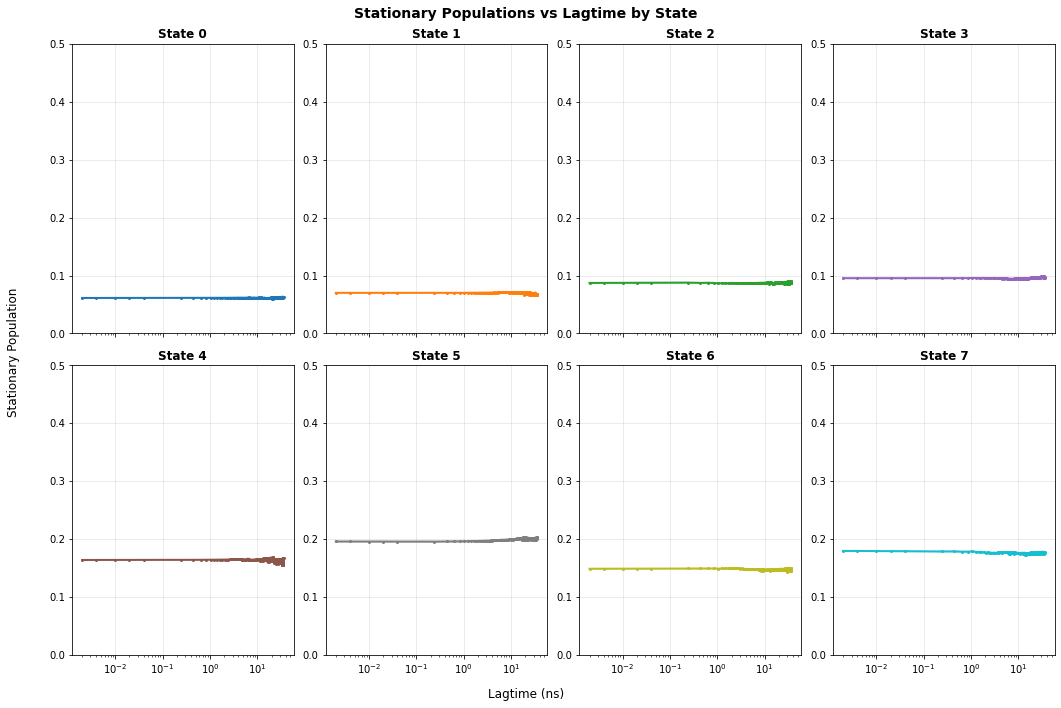

In [ ]:
def plot_stationary_populations_subplots(lagtimes_ns, pi_all_means, pi_all_uppers, pi_all_lowers, 
                                        num_states=8, figsize=(15, 10)):
    """
    Plot stationary populations vs lagtime with separate subplots for each state
    """
    
    # Calculate subplot grid (2x4 for 8 states)
    n_rows = 2
    n_cols = 4
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True)
    axes = axes.flatten()  # Flatten for easy indexing
    
    # Colors for consistency
    colors = plt.cm.tab10(np.linspace(0, 1, num_states))
    
    for state in range(num_states):
        ax = axes[state]
        
        # Plot mean line with confidence bands
        ax.plot(lagtimes_ns, pi_all_means[:, state], 
               color=colors[state], linewidth=2, marker='o', markersize=2)
        
        ax.fill_between(lagtimes_ns, 
                       pi_all_lowers[:, state], 
                       pi_all_uppers[:, state],
                       color=colors[state], alpha=0.3)
        
        # Formatting for each subplot
        ax.set_title(f'State {state}', fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, max(0.5, np.max(pi_all_uppers[:, state]) * 1.1))
        
        # Use log scale for x-axis if needed
        if lagtimes_ns[-1] / lagtimes_ns[0] > 100:
            ax.set_xscale('log')
    
    # Add common labels
    fig.text(0.5, 0.02, 'Lagtime (ns)', ha='center', fontsize=12)
    fig.text(0.02, 0.5, 'Stationary Population', va='center', rotation='vertical', fontsize=12)
    fig.suptitle('Stationary Populations vs Lagtime by State', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08, left=0.08)
    return fig, axes

# Call the subplot version
fig, axes = plot_stationary_populations_subplots(lagtimes_ns, pi_all_means, pi_all_uppers, pi_all_lowers)
plt.show()

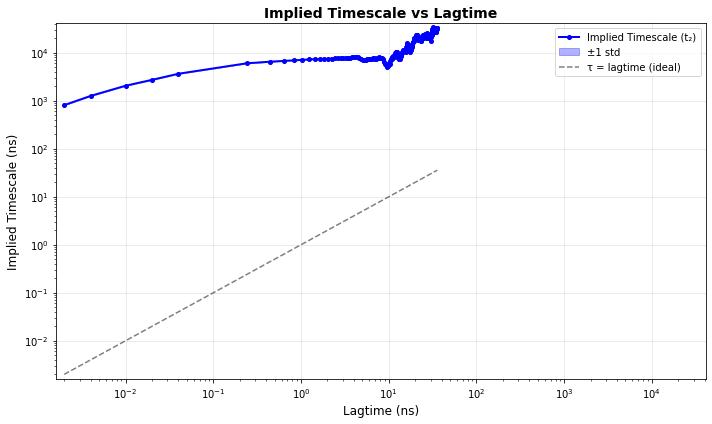

In [ ]:
def plot_implied_timescales(lagtimes_ns, t2_all_means, t2_all_uppers, t2_all_lowers, 
                           figsize=(10, 6)):
    """
    Plot implied timescales vs lagtime
    
    Parameters:
    - lagtimes_ns: array of lagtimes in nanoseconds
    - t2_all_means: array of mean implied timescales
    - t2_all_uppers: array of upper bounds (mean + std)
    - t2_all_lowers: array of lower bounds (mean - std)
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot the mean implied timescale
    ax.plot(lagtimes_ns, t2_all_means, 'b-', linewidth=2, marker='o', 
            markersize=4, label='Implied Timescale (t₂)')
    
    # Plot confidence bands
    ax.fill_between(lagtimes_ns, t2_all_lowers, t2_all_uppers,
                   alpha=0.3, color='blue', label='±1 std')
    
    # Plot the diagonal line (timescale = lagtime)
    # This helps identify equilibration
    ax.plot(lagtimes_ns, lagtimes_ns, 'k--', alpha=0.5, 
            label='τ = lagtime (ideal)')
    
    # Formatting
    ax.set_xlabel('Lagtime (ns)', fontsize=12)
    ax.set_ylabel('Implied Timescale (ns)', fontsize=12)
    ax.set_title('Implied Timescale vs Lagtime', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Use log-log scale for better visualization
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Set reasonable limits
    min_val = min(np.min(lagtimes_ns), np.min(t2_all_lowers[t2_all_lowers > 0]))
    max_val = max(np.max(lagtimes_ns), np.max(t2_all_uppers))
    ax.set_xlim(min_val * 0.8, max_val * 1.2)
    ax.set_ylim(min_val * 0.8, max_val * 1.2)
    
    plt.tight_layout()
    return fig, ax

# Plot implied timescales
fig, ax = plot_implied_timescales(lagtimes_ns, t2_all_means, t2_all_uppers, t2_all_lowers)
plt.show()

# Optional: Save the plot
# plt.savefig('implied_timescales_vs_lagtime.png', dpi=300, bbox_inches='tight')

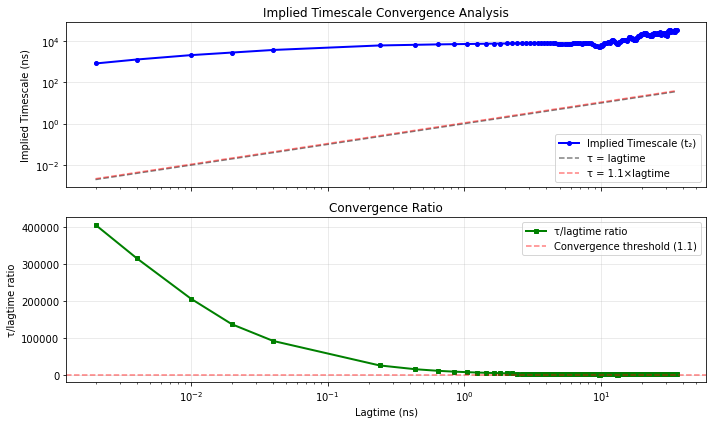

In [ ]:
def plot_timescale_convergence(lagtimes_ns, t2_all_means, threshold_factor=1.1, 
                              figsize=(10, 6)):
    """
    Plot implied timescale convergence with convergence diagnostic
    
    Parameters:
    - threshold_factor: factor for convergence check (timescale should be > threshold_factor * lagtime)
    """
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    # Top plot: Implied timescales
    ax1.plot(lagtimes_ns, t2_all_means, 'b-', linewidth=2, marker='o', 
             markersize=4, label='Implied Timescale (t₂)')
    ax1.plot(lagtimes_ns, lagtimes_ns, 'k--', alpha=0.5, label='τ = lagtime')
    ax1.plot(lagtimes_ns, threshold_factor * lagtimes_ns, 'r--', alpha=0.5, 
             label=f'τ = {threshold_factor}×lagtime')
    
    ax1.set_ylabel('Implied Timescale (ns)')
    ax1.set_title('Implied Timescale Convergence Analysis')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    
    # Bottom plot: Convergence ratio
    convergence_ratio = t2_all_means / lagtimes_ns
    ax2.plot(lagtimes_ns, convergence_ratio, 'g-', linewidth=2, marker='s', 
             markersize=4, label='τ/lagtime ratio')
    ax2.axhline(y=threshold_factor, color='r', linestyle='--', alpha=0.5, 
                label=f'Convergence threshold ({threshold_factor})')
    
    ax2.set_xlabel('Lagtime (ns)')
    ax2.set_ylabel('τ/lagtime ratio')
    ax2.set_title('Convergence Ratio')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    
    plt.tight_layout()
    return fig, (ax1, ax2)

# Plot convergence analysis
fig, axes = plot_timescale_convergence(lagtimes_ns, t2_all_means)
plt.show()

<ipython-input-25-01568e2099ea>:16: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0, 1000)


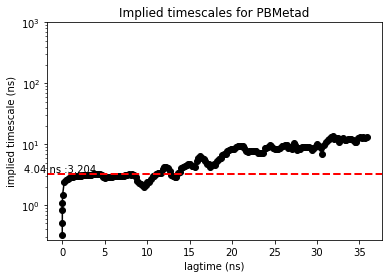

In [ ]:
dt_in_ns = 0.0004

plt.figure()
plt.plot(lagtimes_ns, t2_all_means*dt_in_ns, 'ko-')
plt.fill_between(lagtimes_ns, t2_all_uppers*dt_in_ns, t2_all_lowers*dt_in_ns, alpha=0.2)
plt.xlabel('lagtime (ns)')
plt.ylabel('implied timescale (ns)')

first_x = lagtimes_ns[24]
first_y = t2_all_means[24] * dt_in_ns
first_y_var = t2_all_stds[24]
plt.text(first_x, first_y, f"{first_x} ns :{first_y:.3f}", fontsize=10, ha='right', va='bottom')
plt.axhline(y=first_y, color='r', linestyle='--', linewidth=2)

plt.yscale('log')
plt.ylim(0, 1000)
plt.title(f'Implied timescales for PBMetad')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


8.040000000000001:0.062 +- 0.000


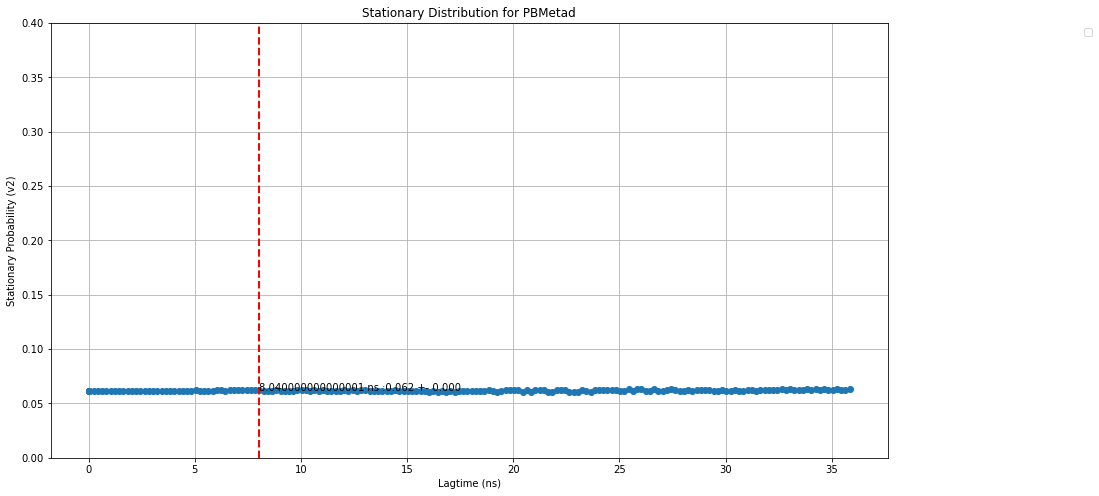

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


8.040000000000001:0.071 +- 0.000


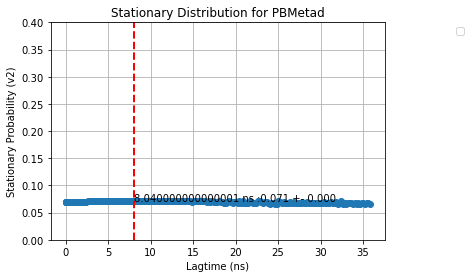

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


8.040000000000001:0.087 +- 0.000


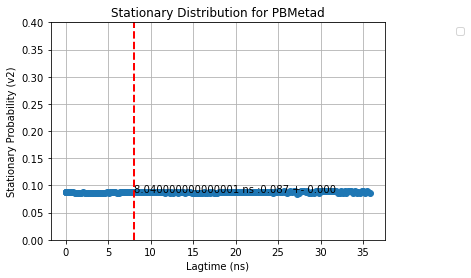

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


8.040000000000001:0.095 +- 0.000


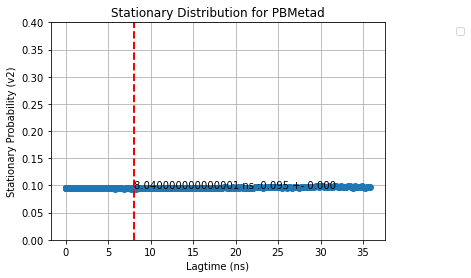

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


8.040000000000001:0.164 +- 0.000


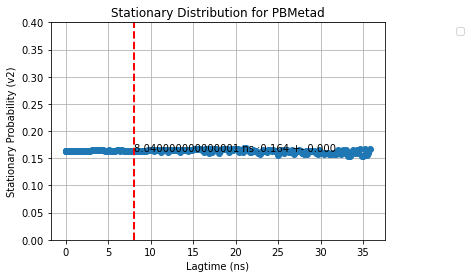

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


8.040000000000001:0.199 +- 0.000


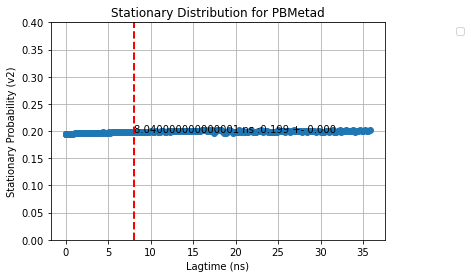

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


8.040000000000001:0.148 +- 0.000


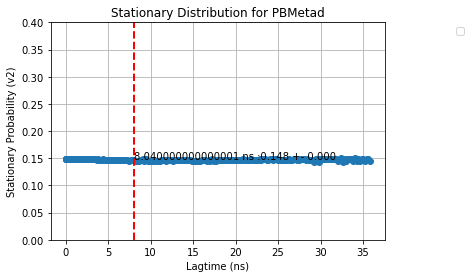

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


8.040000000000001:0.174 +- 0.000


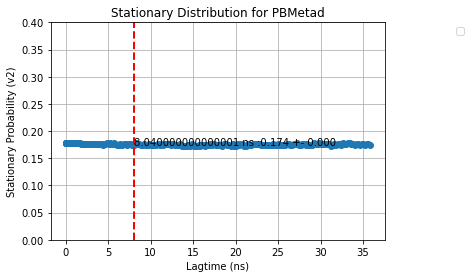

In [ ]:
plt.figure(figsize=(15, 8))
state_to_plot = range(8) # Fix: Select states 0 to 7

# Loop through selected states and plot each separately
for i, state in enumerate(state_to_plot):
    plt.plot(lagtimes_ns, pi_all_means[:, i], '-o') #label=f'State {index_to_state(state)}')
    # Add shaded region for standard deviation
    plt.fill_between(lagtimes_ns,
    pi_all_means[:, i] + pi_all_stds[:, i], # Upper bound
    pi_all_means[:, i] - pi_all_stds[:, i], # Lower bound
    alpha=0.2)

    # Annotate the first point with its value
    first_x = lagtimes_ns[44]
    first_y = pi_all_means[44, i]
    first_y_var = pi_all_stds[44, i]
    plt.text(first_x, first_y, f"{first_x} ns :{first_y:.3f} +- {first_y_var:.3f}", fontsize=10)
    print(f"{first_x}:{first_y:.3f} +- {first_y_var:.3f}")

    plt.axvline(x=first_x, color='r', linestyle='--', linewidth=2)

    plt.xlabel('Lagtime (ns)')
    plt.ylabel('Stationary Probability (v2)')
    plt.title('Stationary Distribution for PBMetad')
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.ylim(0, 0.4)
    plt.grid(True)
    plt.show()

(0.0, 0.3)

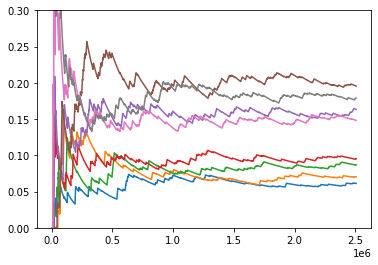

In [ ]:
def calculate_conform_p(trajs, conform_num):
    """
    Calculates the cumulative average population of each conformational state over time,
    excluding NaN values in the trajectory.

    Parameters
    ----------
    trajs : np.ndarray
        A 1D array of shape (timesteps,), where each value is either an integer in 
        [0, conform_num-1] or NaN (for missing data).

    conform_num : int
        The total number of conformational states.

    Returns
    -------
    conform_population : np.ndarray
        Array of shape (conform_num, valid_timesteps) — cumulative average population per conformation.
    """
    trajs = np.asarray(trajs)

    # Only keep valid time steps (non-NaN)
    valid_mask = ~np.isnan(trajs)
    trajs_clean = trajs[valid_mask]
    n_time = trajs_clean.shape[0]

    conform_population = np.zeros((conform_num, n_time), dtype=float)

    for conform_state in range(conform_num):
        match_mask = (trajs_clean == conform_state).astype(float)  # shape: (n_time,)

        cumulative_counts = np.cumsum(match_mask)  # shape: (n_time,)
        time_steps = np.arange(1, n_time + 1)      # shape: (n_time,)

        cumulative_proportions = cumulative_counts / time_steps  # shape: (n_time,)
        conform_population[conform_state] = cumulative_proportions

    #print('Conform population shape:', conform_population.shape)

    return conform_population
conform_num = 8
conform_p = calculate_conform_p(traj_real[0], conform_num)
plt.plot(conform_p.T)
plt.ylim(0, 0.3)

In [ ]:
# Running with Bootstrapping
# traj_indexed = your_trajectory_data  # Shape (1, 200000)
num_states = 8 
lagtimes = [5, 10, 25, 50] + list(range(100, 90000, 500))
dt_in_ns = 0.0004
n_bootstrap_samples = 10  # Number of bootstrap samples to create from your single trajectory

# Store results (same as before)
pi_all_means = []
pi_all_uppers = []
pi_all_lowers = []
pi_all_stds = []
t2_all_means = []
t2_all_uppers = []
t2_all_lowers = []
t2_all_stds = []
for lagtime in tqdm(lagtimes, desc="Processing Lag Times", unit="lag"):
    pi_means, pi_std, t2_mean, t2_std = process_single_trajectory(traj_real, lagtime, num_states, n_bootstrap_samples)
    
    pi_uppers = pi_means + pi_std
    pi_lowers = pi_means - pi_std
    t2_uppers = t2_mean + t2_std
    t2_lowers = t2_mean - t2_std
    
    # Append to results
    pi_all_means.append(pi_means)
    pi_all_uppers.append(pi_uppers)
    pi_all_lowers.append(pi_lowers)
    pi_all_stds.append(pi_std)
    t2_all_means.append(t2_mean)
    t2_all_uppers.append(t2_uppers)
    t2_all_lowers.append(t2_lowers)
    t2_all_stds.append(t2_std)

# Convert to NumPy arrays (same as before)
pi_all_means = np.array(pi_all_means)
pi_all_uppers = np.array(pi_all_uppers)
pi_all_lowers = np.array(pi_all_lowers)
pi_all_stds = np.array(pi_all_stds)
t2_all_means = np.array(t2_all_means)
t2_all_uppers = np.array(t2_all_uppers)
t2_all_lowers = np.array(t2_all_lowers)
t2_all_stds = np.array(t2_all_stds)

lagtimes_ns = np.array(lagtimes) * dt_in_ns

# Print final shapes
print("pi_all_means.shape:", pi_all_means.shape)  # (n_lagtimes, 8)
print("pi_all_stds.shape:", pi_all_stds.shape)    # (n_lagtimes, 8)
print("t2_all_means.shape:", t2_all_means.shape)  # (n_lagtimes,)
print("t2_all_stds.shape:", t2_all_stds.shape)    # (n_lagtimes,)

Processing Lag Times: 100%|██████████| 184/184 [64:23:36<00:00, 1259.87s/lag]    

pi_all_means.shape: (184, 8)
pi_all_stds.shape: (184, 8)
t2_all_means.shape: (184,)
t2_all_stds.shape: (184,)


In [ ]:
# Create an instance of Data with your arrays
data_instance = Data([pi_all_means, pi_all_uppers, pi_all_lowers, pi_all_stds, 
                      t2_all_means, t2_all_uppers, t2_all_lowers, t2_all_stds, lagtimes_ns])

# Save to a file
data_instance.save(f"{data_dir}/stationary_distributions.pkl")